Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menu bar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menu bar, select Cell$\rightarrow$Run All).

Below, please fill in your name and collaborators:

In [44]:
NAME = "Darrah Borinaga"

# Assignment 2 - Time Series Analysis
**(30 points total)**

## Assignment tasks:

In this assignment you will conduct time series analysis of the financial data.

1. Setup your environment to access and download latest stock data. You will use the Yahoo Finance library. To install it, you will need to run this code: pip install yfinance

2. *(4 points)* Download the **adjusted** close prices for FB, MMM, IBM and AMZN for the last 60 months.

3. *(6 points)* Resample the data to get prices for the end of the **business** month. Select the **Adjusted Close** for each stock.

4. *(6 points)* Use the pandas `autocorrelation_plot()` function to plot the autocorrelation of the adjusted month-end close prices for each of the stocks.
    - Are they autocorrelated?
    - Provide short explanation.

5. *(8 points)*
    - Calculate the monthly returns for each stock using the "shift trick" explained in the lecture, using `shift()` function.
    - Use pandas `autotocorrelation_plot()` to plot the autocorrelation of the monthly returns.
    - Are the returns autocorrelated? Provide short explanation.

6. *(6 points)*
    - Combine all 4 time series (returns) into a single DataFrame,
    - Visualize the correlation between the returns of all pairs of stocks using a scatter plot matrix (use `scatter_matrix()` function from `pandas.plotting`).
    - Explain the results. Is there any correlation?

**NOTES:**
1. In this assignment, please make sure the DataFrame(s) do not contain any NAs before you plot autocorrelations or scatter matrix.
2. Both options explained below use `pandas-datareader` package for remote data access. To install it, type the following in a command window: `conda install pandas-datareader`. You will also need to install one or more of the following packages `yfinance`.

---------

### Import all the relevant libraries and follow the examples below for importing data.

In [45]:
import yfinance as yf
from pandas_datareader import data as pdr
import pandas as pd
pd.core.common.is_list_like = pd.api.types.is_list_like
import datetime
import pandas_datareader.data as web

import datetime

start = datetime.datetime.today() - datetime.timedelta(days=365*5)

# Option 1) Using pandas datareader and Yahoo Finance
#yf.pdr_override()

#amzn = pdr.get_data_yahoo('AMZN', start= start )


In [46]:
# Option 2) Using yfinance library only to download AMZN data

amzn = yf.download(
    'AMZN',
    start=start,
    auto_adjust=False
)

amzn.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,,
2021-07-19,177.479507,177.479507,177.510498,174.957993,176.628998,75692000
2021-07-20,178.659500,178.659500,179.600006,175.899994,178.365997,65114000
2021-07-21,179.259995,179.259995,179.322495,177.182007,178.819000,46380000
2021-07-22,181.901505,181.901505,182.001007,179.113495,179.361496,65308000
2021-07-23,182.832001,182.832001,183.305496,181.102005,182.000000,48726000


In [47]:
# If we want to download multipe stocks into a single dataframe:

all_stocks_list = ['AMZN', 'FB', 'IBM', 'MMM']
all_stocks = yf.download(all_stocks_list, start = start)

/tmp/ipykernel_1988/2802993434.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  all_stocks = yf.download(all_stocks_list, start = start)
[*********************100%***********************]  4 of 4 completed


In [48]:
## TYPE YOUE CODE BELOW
# Question 2: Download adjusted closing prices
# for the last 60 months

all_stocks_list = ["AMZN", "META", "IBM", "MMM"]

all_stocks = yf.download(
    all_stocks_list,
    start=start,
    auto_adjust=False,
    progress=False
)

# Select Adjusted Close only
adjusted_close = all_stocks["Adj Close"].copy()

# Rename META to FB to match the assignment
adjusted_close = adjusted_close.rename(
    columns={"META": "FB"}
)

# Arrange the required column order
adjusted_close = adjusted_close[
    ["FB", "MMM", "IBM", "AMZN"]
]

adjusted_close.head()

Ticker,FB,MMM,IBM,AMZN
Date,,,,
2021-07-19,334.016815,138.201202,108.427612,177.479507
2021-07-20,338.685791,140.481720,110.039223,178.659500
2021-07-21,343.216034,140.446716,111.084824,179.259995
2021-07-22,348.132843,139.257523,110.620979,181.901505
2021-07-23,366.570953,140.250839,111.116264,182.832001


In [49]:
adjusted_close.tail()

Ticker,FB,MMM,IBM,AMZN
Date,,,,
2026-07-13,656.729980,157.699997,290.230011,247.309998
2026-07-14,661.039978,156.580002,217.070007,247.490005
2026-07-15,681.309998,160.529999,211.199997,254.960007
2026-07-16,664.539978,161.770004,219.050003,249.889999
2026-07-17,646.010010,159.839996,212.669998,247.229996


In [50]:
adjusted_close.shape

(1255, 4)

In [51]:
all_stocks.head()

Price        Adj Close                                           Close  \
Ticker            AMZN         IBM        META         MMM        AMZN   
Date                                                                     
2021-07-19  177.479507  108.427612  334.016815  138.201202  177.479507   
2021-07-20  178.659500  110.039223  338.685791  140.481720  178.659500   
2021-07-21  179.259995  111.084824  343.216034  140.446716  179.259995   
2021-07-22  181.901505  110.620979  348.132843  139.257523  181.901505   
2021-07-23  182.832001  111.116264  366.570953  140.250839  182.832001   

Price                                                 High              ...  \
Ticker             IBM        META         MMM        AMZN         IBM  ...   
Date                                                                    ...   
2021-07-19  131.854691  336.950012  165.183945  177.510498  132.399612  ...   
2021-07-20  133.814529  341.660004  167.909698  179.600006  138.546844  ...   
2021-07-21  135.086044  346.230011  167.867889  179.322495  135.172089  ...   
2021-07-22  134.521988  351.190002  166.446487  182.001007  135.573608  ...   
2021-07-23  135.124283  369.790009  167.633774  183.305496  135.468445  ...   

Price              Low                    Open                          \
Ticker            META         MMM        AMZN         IBM        META   
Date                                                                     
2021-07-19  334.540009  163.135452  176.628998  130.449326  337.570007   
2021-07-20  334.500000  165.610367  178.365997  136.711288  338.799988   
2021-07-21  341.250000  167.190628  178.819000  133.814529  341.500000   
2021-07-22  345.209991  166.120407  179.361496  135.430206  346.679993   
2021-07-23  357.190002  166.337799  182.000000  134.761002  360.910004   

Price                     Volume                               
Ticker             MMM      AMZN       IBM      META      MMM  
Date                                                           
2021-07-19  165.376251  75692000   8977086  14372300  3762975  
2021-07-20  165.836121  65114000  14237838  11024300  3328827  
2021-07-21  168.168900  46380000   5024984   9279700  2390924  
2021-07-22  168.486618  65308000   3466653  12385400  2033798  
2021-07-23  167.650497  48726000   4680013  33694300  1878557  

[5 rows x 24 columns]

In [52]:
# Question 3
# Resample to Business Month-End

monthly_prices = adjusted_close.resample("BM").last()

monthly_prices.head()

/tmp/ipykernel_1988/693165147.py:4: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  monthly_prices = adjusted_close.resample("BM").last()


Ticker,FB,MMM,IBM,AMZN
Date,,,,
2021-07-30,353.198334,138.467041,110.817520,166.379501
2021-08-31,376.077454,137.268402,111.600349,173.539505
2021-09-30,336.435608,123.650108,110.479073,164.251999
2021-10-29,320.753296,125.948021,99.481270,168.621506
2021-11-30,321.635529,120.833282,98.702805,175.353500


In [53]:
monthly_prices.tail()

Ticker,FB,MMM,IBM,AMZN
Date,,,,
2026-03-31,571.600220,144.482773,240.619049,208.270004
2026-04-30,611.343384,145.766144,229.292404,265.059998
2026-05-29,631.924316,153.130005,297.799988,270.640015
2026-06-30,563.289978,161.910004,281.209991,238.339996
2026-07-31,646.010010,159.839996,212.669998,247.229996


In [54]:
monthly_prices.shape

(61, 4)

In [55]:
monthly_prices.isna().sum()

,0
Ticker,
FB,0
MMM,0
IBM,0
AMZN,0


In [56]:
monthly_prices = monthly_prices.dropna()

In [57]:
# last business (trading) day of the month

monthly_prices.head()

Ticker,FB,MMM,IBM,AMZN
Date,,,,
2021-07-30,353.198334,138.467041,110.817520,166.379501
2021-08-31,376.077454,137.268402,111.600349,173.539505
2021-09-30,336.435608,123.650108,110.479073,164.251999
2021-10-29,320.753296,125.948021,99.481270,168.621506
2021-11-30,321.635529,120.833282,98.702805,175.353500


In [58]:
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt

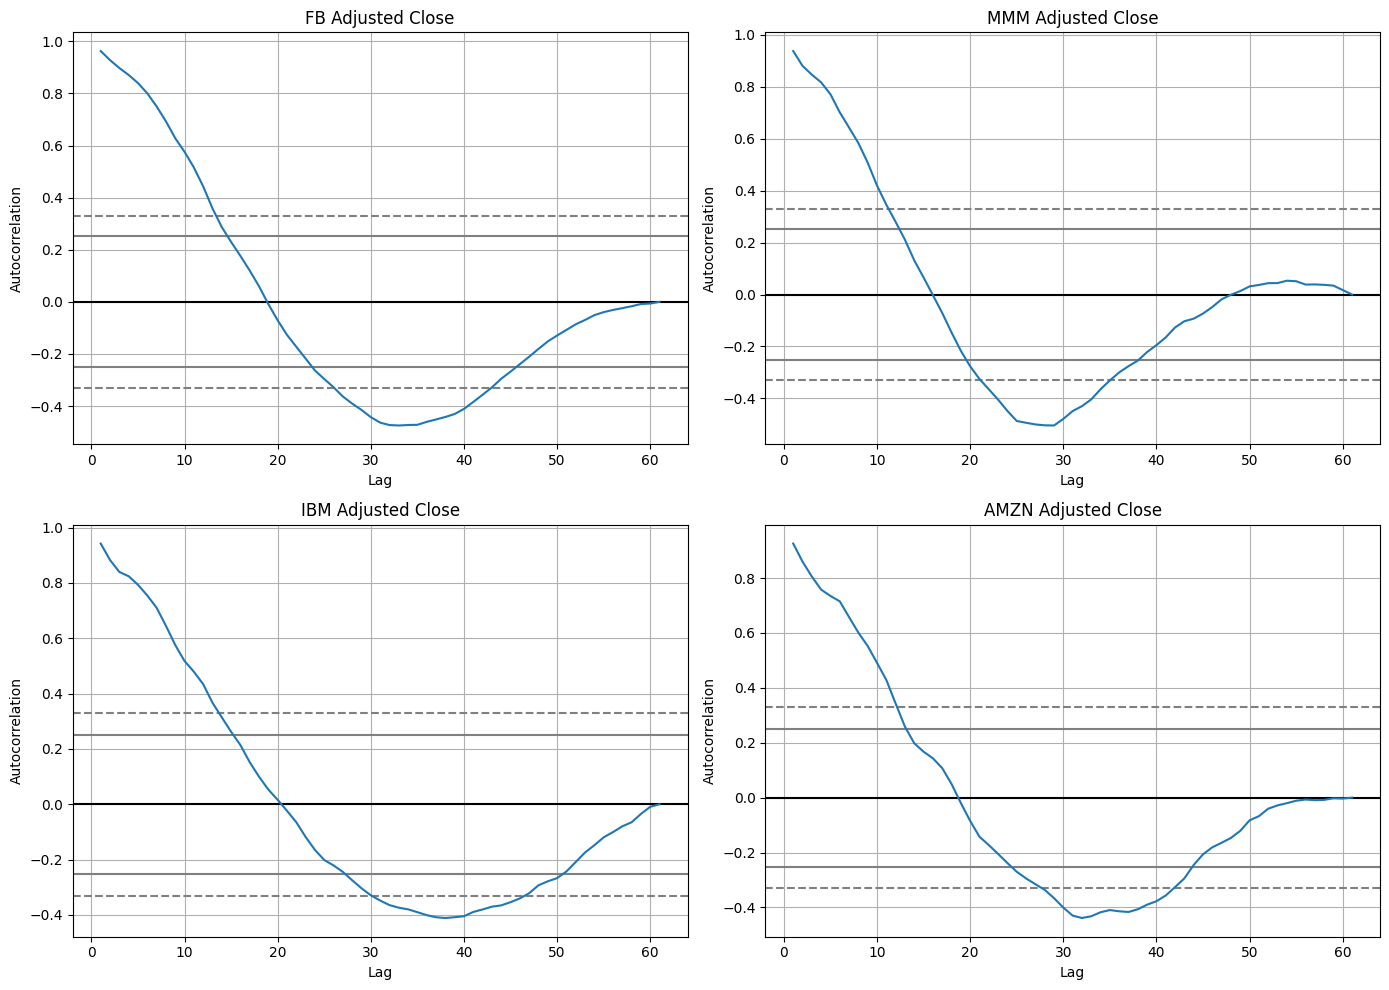

In [59]:
# Question 4
# Autocorrelation of Adjusted Month-End Close Prices

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stocks = monthly_prices.columns

for ax, stock in zip(axes.flatten(), stocks):
    autocorrelation_plot(monthly_prices[stock], ax=ax)
    ax.set_title(f"{stock} Adjusted Close")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

In [60]:
print("Lag-1 Autocorrelation")

for stock in monthly_prices.columns:
    print(
        f"{stock}:",
        round(monthly_prices[stock].autocorr(lag=1), 4)
    )

Lag-1 Autocorrelation
FB: 0.9741
MMM: 0.9584
IBM: 0.9528
AMZN: 0.9453


**Are the stock prices autocorrelated?**

Yes.

The adjusted month-end closing prices show strong positive autocorrelation. This means that the stock price in one month is highly related to the price in the previous month. Stock prices generally move gradually over time rather than changing independently from one month to the next. Therefore, the autocorrelation plots display strong positive correlations at lower lags, indicating persistence in the price series.

In [61]:
# Question 5
# Calculate Monthly Returns using the Shift Trick

monthly_returns = (
    monthly_prices - monthly_prices.shift(1)
) / monthly_prices.shift(1)

# Remove the first row (contains NaN)
monthly_returns = monthly_returns.dropna()

monthly_returns.head()

Ticker,FB,MMM,IBM,AMZN
Date,,,,
2021-08-31,0.064777,-0.008656,0.007064,0.043034
2021-09-30,-0.105409,-0.099209,-0.010047,-0.053518
2021-10-29,-0.046613,0.018584,-0.099546,0.026602
2021-11-30,0.002751,-0.040610,-0.007825,0.039924
2021-12-31,0.036646,0.044636,0.141418,-0.049252


In [62]:
monthly_returns.isna().sum()

,0
Ticker,
FB,0
MMM,0
IBM,0
AMZN,0


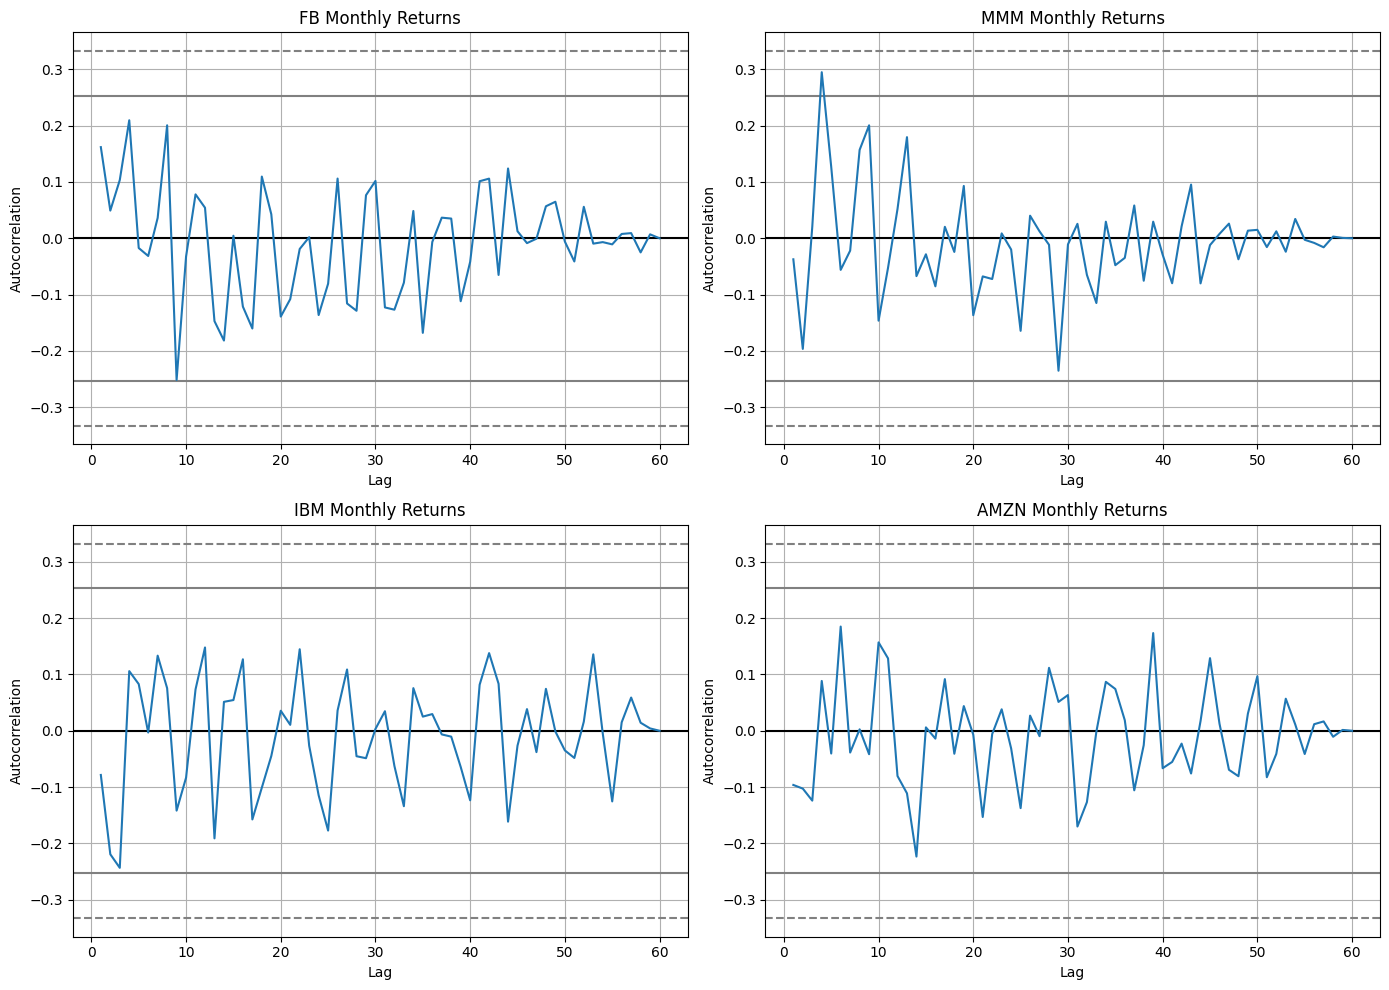

In [63]:
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stocks = monthly_returns.columns

for ax, stock in zip(axes.flatten(), stocks):
    autocorrelation_plot(monthly_returns[stock], ax=ax)
    ax.set_title(f"{stock} Monthly Returns")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

In [64]:
print("Lag-1 Autocorrelation of Monthly Returns")

for stock in monthly_returns.columns:
    print(
        f"{stock}:",
        round(monthly_returns[stock].autocorr(lag=1), 4)
    )

Lag-1 Autocorrelation of Monthly Returns
FB: 0.1636
MMM: -0.0374
IBM: -0.0846
AMZN: -0.0964


**Are the monthly returns autocorrelated?**

Generally, no.

The monthly returns exhibit weak or no significant autocorrelation. Most autocorrelation values are close to zero, indicating that returns from one month do not consistently predict returns in the following month. Unlike stock prices, which usually move gradually over time, monthly returns fluctuate around zero and are more random. This behavior is consistent with the efficient market hypothesis, which suggests that past returns provide limited information for predicting future returns.


In [65]:
# Question 6
# Combine all four return series

returns_df = monthly_returns[
    ["FB", "MMM", "IBM", "AMZN"]
].copy()

# Remove any missing values
returns_df = returns_df.dropna()

returns_df.head()

Ticker,FB,MMM,IBM,AMZN
Date,,,,
2021-08-31,0.064777,-0.008656,0.007064,0.043034
2021-09-30,-0.105409,-0.099209,-0.010047,-0.053518
2021-10-29,-0.046613,0.018584,-0.099546,0.026602
2021-11-30,0.002751,-0.040610,-0.007825,0.039924
2021-12-31,0.036646,0.044636,0.141418,-0.049252


In [66]:
returns_df.isna().sum()

,0
Ticker,
FB,0
MMM,0
IBM,0
AMZN,0


In [67]:
correlation_matrix = returns_df.corr()

print("Correlation Matrix")

correlation_matrix

Correlation Matrix


Ticker,FB,MMM,IBM,AMZN
Ticker,,,,
FB,1.000000,0.091918,0.153701,0.463835
MMM,0.091918,1.000000,0.296376,0.181766
IBM,0.153701,0.296376,1.000000,0.076659
AMZN,0.463835,0.181766,0.076659,1.000000


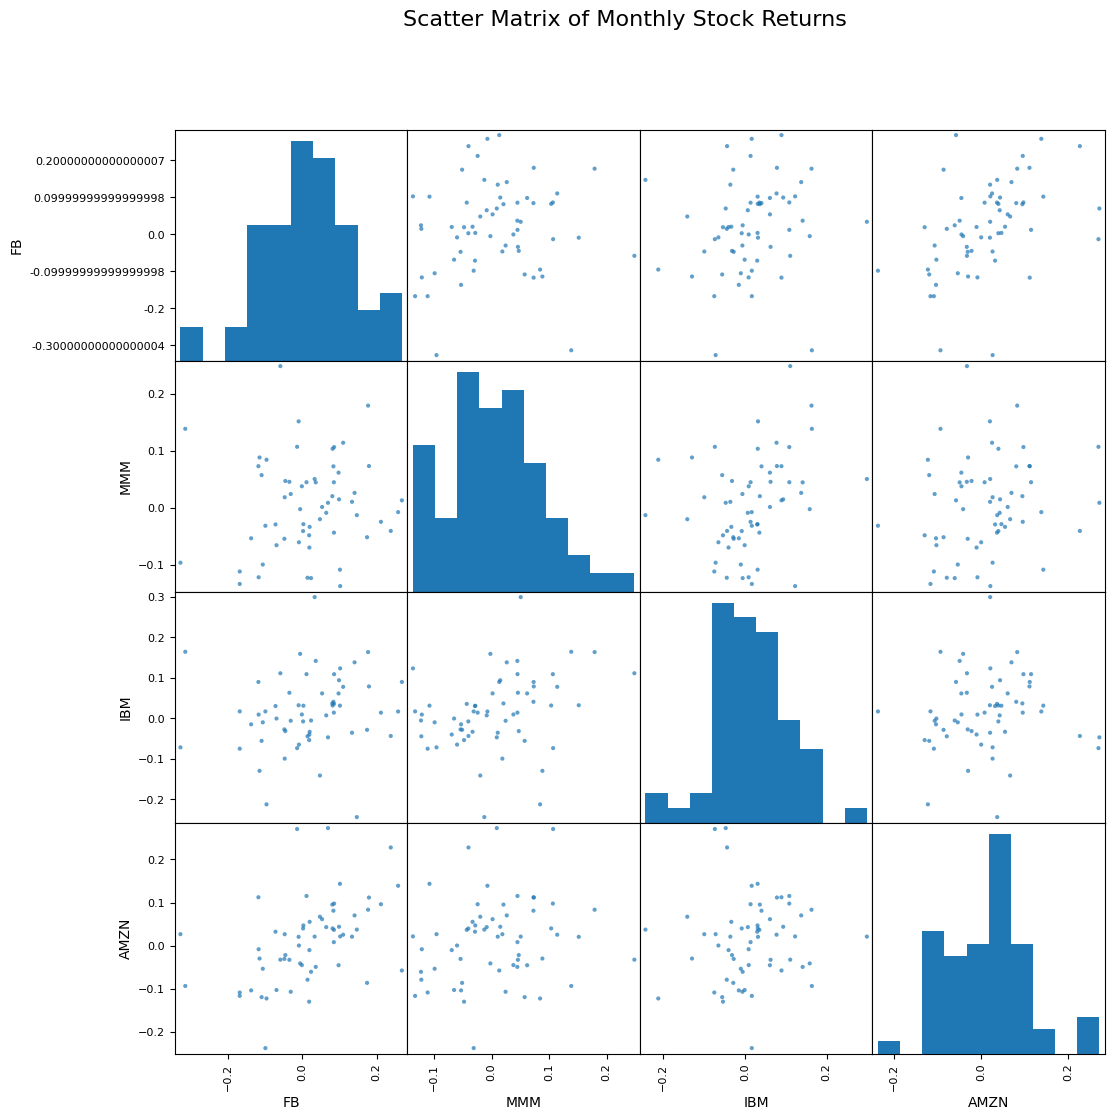

In [68]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

scatter_matrix(
    returns_df,
    figsize=(12, 12),
    diagonal="hist",
    alpha=0.7
)

plt.suptitle(
    "Scatter Matrix of Monthly Stock Returns",
    fontsize=16
)

plt.show()

**Is there correlation?**

Yes, there is some positive correlation, but it is generally moderate rather than perfect.

The scatter plot matrix and correlation matrix indicate that several stock pairs have positive correlations, meaning they tend to move in the same direction during some months. However, the relationships are not perfectly linear, as shown by the scattered point patterns. Technology companies such as Facebook (Meta) and Amazon may exhibit stronger correlations because they operate in related sectors, while 3M and IBM may show weaker relationships due to differences in their industries. Overall, the correlations suggest that market-wide economic factors influence all stocks, but each company also experiences unique business-specific risks.

In [69]:
print("Missing Values")
print(returns_df.isna().sum())

print("\nShape")
print(returns_df.shape)

print("\nColumns")
print(returns_df.columns)

Missing Values
Ticker
FB      0
MMM     0
IBM     0
AMZN    0
dtype: int64

Shape
(60, 4)

Columns
Index(['FB', 'MMM', 'IBM', 'AMZN'], dtype='object', name='Ticker')
